# Predict KL Divergence from Catchment Attributes

## Introduction

We compute the ordinary and linear moment statistics of runoff time series for a large sample of catchments. We then test the predictability of these statistics from catchment attributes using a gradient boosting machine learning approach.  The purpose of testing predictability of the order statistics and L-moments is to fully describe parametric distributions for estimating streamflow distributions (flow duration curves), a common problem in applied hydrology.

Catchment attributes are used as predictors of each order statistic.  Attributes are added cumulatively in successive tests to compare the contribution of catchment attribute groups related to climate, terrain, land cover, and soil.  

We test if transforming the target variable has an effect on the xgboost model. For transformations that do not change the rank of the target variable, i would not expect to see an effect, however the metric used as the objective function may be sensitive to the distribution of target variables, that is sensitive to outliers.  We test the predictability of the following:

Skewness / Kurtosis (classical) tell you about asymmetry and tail‐heaviness, but can be noisy when your sample has extremes, which is a common issue in hydrology.  L-moments are linear combinations of order‐statistics, and are considered more robust under heavy tails.


In [2]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
import xarray as xr
from scipy.stats import skew, kurtosis
from math import comb

from bokeh.plotting import figure, show
from bokeh.layouts import gridplot, row, column
from bokeh.models import HoverTool, ColumnDataSource, Whisker, Legend, LegendItem
from bokeh.transform import factor_cmap, factor_mark
from bokeh.palettes import Category10, Category20, Category20c, Viridis
from bokeh.io import output_notebook
# from bokeh.palettes import Sunset10, Vibrant7
from pathlib import Path

import xgboost as xgb

import data_processing_functions as dpf

from scipy.stats import linregress
output_notebook()

BASE_DIR = os.getcwd()

Loading BokehJS ...

Loading BokehJS ...

In [3]:
# There is a ragged list construction warning in the xgb.train()
# # function because of the early stopping making eval_lists different lengths
# import warnings
# warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)


## Load Input Data

### Extra catchments to exclude

* Kakuhan Creek Near Haines AK - 15056030

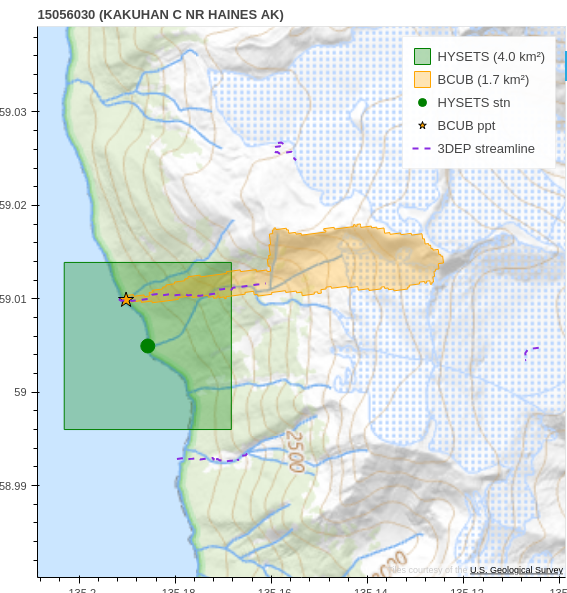

### Excluded due to no complete years of data >= 90% complete

* Genessee Creek at the Mouth - 08FA009
* McNair Creek near Port Mellon - 08GA037
* Canoe River near Valemount - 08NC003
* Big Quilcene River Near Quilcene, WA - 12052500
* Morey Creek above McChord Afb near Parkland, WA - 12090480
* North Fork Newaukum Creek Near Enumclaw, WA - 12107950
* Newaukum Creek Tributary Near Blacik Diamond, WA - 12108450
* May Creek near Issaquah, WA - 12119300
* Honey Creek near Renton, WA - 12119450
* Carpenter Creek near Bacon Rod near Mount Vernon, WA - 12200684
* Unnamed Tributary Massacre Bay on Orcas Island, WA - 12200762
* Whatcom Creek near Bellingham, WA - 12203000
* Hall Creek at Inchelium, WA - 12409500
* Dayebas Creek Near Haines, AK - 15056070
* Bonne Creek near Klawock, AK - 15081510

In [4]:
# load the catchment characteristics
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
attr_gdf = gpd.read_file(DATA_DIR / 'stn_attributes_with_5_spatial_partitions.geojson')
# # map the cluster numbers to the attributes dataframe
cluster_dict = attr_gdf.set_index('official_id')['5_spatial'].to_dict()

## Define attribute groups

In [5]:
terrain = ['drainage_area_km2', 'elevation_m', 'slope_deg', 'aspect_deg']
land_cover = [
    'land_use_forest_frac_2010', 'land_use_grass_frac_2010', 'land_use_wetland_frac_2010', 'land_use_water_frac_2010', 
    'land_use_urban_frac_2010', 'land_use_shrubs_frac_2010', 'land_use_crops_frac_2010', 'land_use_snow_ice_frac_2010']
climate = ['prcp', 'srad', 'swe', 'tmax', 'tmin', 'vp', 'high_prcp_freq', 'high_prcp_duration', 'low_prcp_freq', 'low_prcp_duration']
soil = ['logk_ice_x100', 'porosity_x100']

all_attributes = terrain + land_cover + soil + climate
len(all_attributes)

24

In [6]:
results_folder = os.path.join(BASE_DIR, 'data', 'KLD_prediction_results')
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

In [7]:
all_test_results = {}
attribute_set_dict = {
    'climate': climate, 
    '+land_cover': land_cover,
    '+terrain': terrain, 
    '+soil': soil,
}

## Set Attribute Groupings

In [8]:
group_1 = ['climate', '+terrain', '+land_cover', '+soil']
# for group 2, just reverse group 1
group_2 = group_1[::-1]
group_3 = ['+land_cover', '+terrain', '+soil', 'climate']
group_4 = ['+soil', 'climate', '+land_cover', '+terrain']
attribute_group_orders = [group_1]#[group_1, group_2, group_3, group_4]

In [9]:
# create the fold dictionary to initialize the train/test split for each fold
def create_fold_dict(df):
    cluster_ids = [int(e) for e in sorted(list(set(attr_gdf['5_spatial'].values)))]
    print(f'The fold ids are: {cluster_ids}')
    fold_dict = {}
    for c in cluster_ids:
        cluster_stns = attr_gdf.loc[attr_gdf['5_spatial'] == c, 'official_id'].values
        # in-group edges
        dkl_sample_AND = df[(df['donor'].isin(cluster_stns)) & (df['target'].isin(cluster_stns))].copy()
        # out-of-group edges
        dkl_sample_NOR = df[(~df['donor'].isin(cluster_stns)) & (~df['target'].isin(cluster_stns))].copy()
        # assert that these are mutually exclusive groups
        and_official_ids = set(dkl_sample_AND['donor'].values) | set(dkl_sample_AND['target'].values)
        nor_official_ids = set(dkl_sample_NOR['donor'].values) | set(dkl_sample_NOR['target'].values)
        assert len(and_official_ids & nor_official_ids) == 0, 'stations in list are not unique'
        fold_dict[c] = {
            'test': dkl_sample_AND.index.values,
            'train': dkl_sample_NOR.index.values,
        }
    return fold_dict 

In [10]:
def format_features(input_attributes):
    features = []
    for a in input_attributes:
        features.append(f"donor_{a}".lower())
        features.append(f"target_{a}".lower())
    return features

def add_attributes(attr_df, df, attribute_cols):
    """
    Adds attributes from the df_attributes to the df_relations based on the 'donor' and 'target' columns
    using map for efficient lookups.

    Parameters:
    df_attributes (pd.DataFrame): DataFrame with 'id' and attribute columns.
    df_relations (pd.DataFrame): DataFrame with 'donor' and 'target' columns.
    attribute_cols (list of str): List of attribute columns to add to df_relations.

    Returns:
    pd.DataFrame: Updated df_relations with added attribute columns.
    """
    # Create dictionaries for each attribute for quick lookup
    attr_dicts = {col: attr_df.set_index('official_id')[col].to_dict() for col in attribute_cols}

    # Add target attributes
    for col in attribute_cols:
        df[f'target_{col}'] = df['target'].map(attr_dicts[col])

    # Add donor attributes
    for col in attribute_cols:
        df[f'donor_{col}'] = df['donor'].map(attr_dicts[col])
    for col in attribute_cols:
        df[f'{col}_diff'] = df[f'target_{col}'] - df[f'donor_{col}'] 

    return df

## Run XGBoost Regression

The same problem setup applies for the regression prediction problem which is to optimize the discriminant function and the input signal quantization simultaneously to minimize the error in predicting the KL divergence from catchment attributes.

Instead of predicting a scalar measure which is a feature of a single location, the key difference in this step is the target variable describes a measure of the difference in runoff between **pairs of locations**. This approach asks whether the **Kullback-Leibler Divergence** (KLD) of the distribution of unit area runoff between two locations can be predicted from the attributes of both catchments (and their differences) using the gradient boosted decision tree method, which is also capable of predicting continuous variables, in this case $D_\text{KL}$.

#### Set trial parameters

In [11]:
# define the amount of data to set aside for final testing
random_seed = 42
nfolds = 5
n_boost_rounds = 2500
n_optimization_rounds = 10
# loss = 'reg:squarederror'
loss = 'reg:absoluteerror'

# cross validation parameters
optimize_cv_folds = False
cv_fold_seed = 83561
# limit the maximum distance to make the network 
# graph of station pairs more separable
max_centroid_distance = 400

attribute_set_names = ['proximity', '+climate', '+terrain', '+land_cover', '+soil']
attribute_group_sets = [['centroid_distance_km'], climate, terrain, land_cover, soil]

posterior_columns = ['kld']

### Train-test split

The input dataset is pairwise comparisons of just over 1300 (streamflow) monitored catchments, their attributes, and the attribute differences. After filtering for data concurrency (minimum 1 year, < 5 days missing per month) and maximum distance between basin centroids (500 km) we are left with roughly 225K pairs. The pairwise setup means that station data appears in more than one row. As a result, the attributes of stations can end up in both training and test sets if we simply split by randomly assigning rows to training or test sets. We can’t simply cut edges until the graph is separated because it is a generalization of the [“keeping a subset of vertices” problem in graph theory](https://en.wikipedia.org/wiki/Independent_set_(graph_theory)) which is NP-hard.

To address this issue we split the dataset spatially to create partitioned datasets for each fold and draw samples from within the “cluster” while filtering all edges between the fold and the rest of the set. The end goal is to generate training folds where the `official_id` does not appear in both training and test set, in either donor or target column. One problem remains, and that is to generate training and test sets with some assurance that the target variable distributions match to some degree, but this is less critical than ensuring there is no data leakage between training and test data.

Next we create training/test splits and visualize how the target variable distributions compare.

In [16]:
def compute_empirical_cdf(data):
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, cdf

def verify_no_leakage(input_data, fold_dict):
    """Verify no station appears in multiple splits of same fold (data leakage check)."""
    leakage_summary = []
    print("\n=== Data Leakage Verification ===")
    for fold_id, cv_data in fold_dict.items():
        print(cv_data)
        train_idxs = cv_data['train']
        val_idxs = cv_data['validation']
        test_idxs = cv_data['test']
        
        # Extract station IDs from each split
        train_stns = set(input_data.loc[train_idxs, 'donor'].values) | set(input_data.loc[train_idxs, 'target'].values)
        val_stns = set(input_data.loc[val_idxs, 'donor'].values) | set(input_data.loc[val_idxs, 'target'].values)
        test_stns = set(input_data.loc[test_idxs, 'donor'].values) | set(input_data.loc[test_idxs, 'target'].values)
        
        # Check overlaps
        train_val_overlap = train_stns & val_stns
        val_test_overlap = val_stns & test_stns
        train_test_overlap = train_stns & test_stns
        
        assert len(train_val_overlap) == 0, f"Fold {fold_id}: stations in both train and val"
        assert len(val_test_overlap) == 0, f"Fold {fold_id}: stations in both val and test"
        assert len(train_test_overlap) == 0, f"Fold {fold_id}: stations in both train and test"
        
        summary = {
            'fold': fold_id,
            'n_train': len(train_idxs),
            'n_validation': len(val_idxs),
            'n_test': len(test_idxs),
            'n_train_stations': len(train_stns),
            'n_val_stations': len(val_stns),
            'n_test_stations': len(test_stns),
        }
        leakage_summary.append(summary)
        print(f"Fold {fold_id}: train={len(train_idxs)} pairs ({len(train_stns)} stn), "
              f"val={len(val_idxs)} pairs ({len(val_stns)} stn), "
              f"test={len(test_idxs)} pairs ({len(test_stns)} stn)")
    
    print("✓ No data leakage detected\n")
    return leakage_summary

def train_xgb_model(
    input_data, fold_no, cv_data, attributes, target, params, num_boost_rounds, log_transform_target=False
):    
    test_idxs = cv_data['test']
    train_idxs = cv_data['train']   

    test_data = input_data.iloc[test_idxs, :].copy()
    train_data = input_data.iloc[train_idxs, :].copy()

    X_train = train_data[attributes].values
    X_test = test_data[attributes].values
    
    if log_transform_target:
        Y_train = np.log(train_data[target].values)
        Y_test = np.log(test_data[target].values)
    else:
        Y_train = train_data[target].values
        Y_test = test_data[target].values

    # model = xgb.XGBRegressor(**params)

    dtrain = xgb.DMatrix(X_train, label=Y_train)
    dtest = xgb.DMatrix(X_test, label=Y_test)

    eval_list = [(dtrain, "train"), (dtest, "eval")]
    evals_result = {}
    bst = xgb.train(
        params,
        dtrain,
        num_boost_rounds,
        evals=eval_list,
        evals_result=evals_result,
        verbose_eval=0,
    )
    eval_keys = list(evals_result['train'].keys())
    if len(eval_keys) > 1:
        print(f' setting eval key to {eval_keys[0]} from {eval_keys}')

    eval_key = eval_keys[0]
    # Convert the lists to NumPy arrays with dtype=object
    train_perf = np.array(evals_result['train'][eval_key], dtype=object)
    test_perf = np.array(evals_result['eval'][eval_key], dtype=object)
    fold_progress = pd.DataFrame({
        'train': evals_result['train'][eval_key],
        'test': evals_result['eval'][eval_key],
        'fold': [fold_no]*len(evals_result['train'][eval_key]),
    })
    predicted = bst.predict(dtest)

    return train_perf, test_perf, fold_progress, predicted, Y_test

In [17]:
def run_xgb_trials_custom_CV(
    set_name,
    attributes,
    target,
    input_data,
    fold_dict, 
    n_optimization_rounds,
    num_boost_rounds,
    results_folder,
    bits,
    loss='reg:squarederror',
    random_seed=42,
    log_transform_target=False,
):
    """
    Custom CV refers to cross validation.  Custom cross validation means the 
    held-out set must be determined in a more robust way to avoid "data leakage".
    That is, the pairs making up the training, validation, and test sets must 
    be made up of pairings from unique sets of stations.
    
    5-fold spatial cross-validation: Each fold's test set contains pairs where 
    BOTH stations belong to one spatial cluster; training set contains pairs 
    where NEITHER station is in that cluster. This spatial isolation prevents 
    data leakage even when selecting hyperparameters based on test performance.
    """
    # select random hyperparameters for n_optimization_rounds
    sample_choices = np.arange(0.5, 0.9, 0.02)  # subsample and colsample percentages
    lr_choices = np.arange(0.0001, 0.05, 0.0002)  # learning rates
    learning_rates = np.random.choice(lr_choices, n_optimization_rounds)
    subsamples = np.random.choice(sample_choices, n_optimization_rounds)
    colsamples = np.random.choice(sample_choices, n_optimization_rounds)
    num_boost_rounds = num_boost_rounds
    eval_key = loss.split(':')[1]

    all_results = []
    output_target_cdfs = None
    best_mean_test_perf = float("inf")  # SELECT HYPERPARAMETERS ON TEST within CV (spatial isolation prevents leakage)

    for trial in range(n_optimization_rounds):
        lr, ss, cs = learning_rates[trial], subsamples[trial], colsamples[trial]
        params = {
            "objective": loss,
            "eta": lr,
            # "max_depth": 6,  # use default max_depth
            # "min_child_weight": 1, # use colsample and subsample instead of min_child_weight
            "subsample": ss,  #  random subsampling of rows to prevent overfitting
            "colsample_bytree": cs, # random subsampling of columns to prevent overfitting
            "seed": random_seed,
            "device": "cuda",  # CUDA GPU
            "sampling_method": "gradient_based",
            "tree_method": "hist",
        }

        results_fname = (
            f"{set_name}_{bits}_{lr:.3f}_lr_{ss:.3f}_sub_{cs:.3f}_col.csv"
        )
        results_fpath = os.path.join(results_folder, results_fname)

        # k-fold cross validation
        all_fold_results = []
        fold_arrays = []
        best_val_rounds, best_test_rounds = [], []
        target_cdfs = []
        
        for fold_no, cv_data in fold_dict.items():
            train_perf, test_perf, fold_progress, predicted, Y_test = train_xgb_model(
                input_data,
                fold_no,
                cv_data,
                attributes,
                target,
                params,
                num_boost_rounds,
                log_transform_target=log_transform_target
            )            
            fold_arrays.append(fold_progress)

            test_ids = input_data.loc[cv_data['test'], ['donor', 'target']].values
            test_ids = [f'{e[0]}_{e[1]}' for e in test_ids]

            test_results = pd.DataFrame(
                {"predicted": predicted, "actual": Y_test, "station_pair": test_ids}
            )
            
            ordered_data, fold_cdf = compute_empirical_cdf(Y_test)
            target_cdfs += [(ordered_data, fold_cdf)]
            
            # Get best round based on TEST set performance (within CV fold)
            # This is valid because each fold's test set is spatially isolated from training
            best_perf_round_test = np.argmin(test_perf)
            test_perf_best = test_perf[best_perf_round_test]
            best_test_rounds.append(test_perf_best)
            
            all_fold_results.append(test_results)

        all_test_predictions_df = pd.concat(all_fold_results)
        convergence_df = pd.concat(fold_arrays)

        mean_test_perf = np.mean(best_test_rounds)  # Test metric for hyperparameter selection (spatially isolated)
        median_test_perf = np.median(best_test_rounds)
        stdev_test_perf = np.std(best_test_rounds)
        
        # Track the trial error metrics
        results_dict = {
            'trial': trial,
            f'test_{eval_key}_mean': mean_test_perf,
            f'test_{eval_key}_median': median_test_perf,
            f'test_{eval_key}_stdev': stdev_test_perf,
        }
        
        results_dict.update(params)
        all_results.append(results_dict)
        if (trial > 0) & (trial % 10 == 0):
            print(f"   completed {trial}/{n_optimization_rounds}")
            
        # SELECT BEST BASED ON TEST PERFORMANCE (spatial isolation prevents leakage)
        if round(mean_test_perf, 2) < round(best_mean_test_perf, 2):
            best_params = params
            best_mean_test_perf = mean_test_perf
            best_convergence_df = convergence_df
            best_trial_test_predictions = all_test_predictions_df
            output_target_cdfs = target_cdfs
            print(f'    New best result: test_{eval_key}={mean_test_perf:.2f} (trial {trial})')
    
    # save the best trial results
    best_trial_test_predictions.to_csv(results_fpath)
    results_all_trials = pd.DataFrame(all_results)
    # get the mean and standard deviation of the error metrics over all trials
    all_trials_test_mean = results_all_trials[f"test_{eval_key}_mean"].mean()
    all_trials_test_stdev = results_all_trials[f"test_{eval_key}_mean"].std()
    print(
        f"    Test {eval_key}: {all_trials_test_mean:.2f} ± {2*all_trials_test_stdev:.3f} (95% CI) (of {len(results_all_trials)} hyperparameter optimization rounds.)"
    )
    return best_params, best_mean_test_perf, best_convergence_df, best_trial_test_predictions, results_all_trials, output_target_cdfs

In [18]:
def predict_KLD_from_attributes(bits, df, target_variable, results_folder,
                                loss_function=None, n_boost_rounds=100, random_seed=42, 
                              n_cv_fold_optimization_trials=20, log_transform_target=False):

    all_results = {}
    fold_dict = create_fold_dict(df)

    # add attribute groups successively
    predictor_attributes = []
    # make sure the order of attributes matches the attribute_set_names list
    for attribute_set, set_name in zip(attribute_group_sets, attribute_set_names):
        print(f'  Processing {set_name} attribute set: {target_variable} ({bits} bits)')
        
        # initialize the predictor variables (features)
        predictor_attributes += attribute_set
        if set_name == 'proximity':
            features = ['centroid_distance_km']
        else:
            non_dist_features = [c for c in predictor_attributes if c != 'centroid_distance_km']
            pair_features = format_features(non_dist_features)
            diff_features = [f'{c}_diff' for c in non_dist_features]
            features = ['centroid_distance_km'] + pair_features + diff_features                

        best_params, best_mean_rmse, best_convg_df, best_trial_test_predictions, results_all_trials, target_cdfs = run_xgb_trials_custom_CV(
                set_name, features, target_variable, df, fold_dict, 
                n_cv_fold_optimization_trials, n_boost_rounds, results_folder, bits, loss=loss_function, random_seed=random_seed,
                log_transform_target=log_transform_target,
        )
        # store the test set predictions and actuals
        all_results[set_name] = {
            'best_params': best_params,
            'all_results': results_all_trials, 
            'convergence': best_convg_df,
            'oos_predictions': best_trial_test_predictions,
            # 'test_rmse': best_mean_rmse,
            'test_mae': best_mean_rmse,
            'target_cdfs': target_cdfs,
        } 
    return all_results

In [19]:
# ===================================================================
# PHASE 1: BASELINE VERIFICATION & DATA LEAKAGE CHECK
# ===================================================================
print("=" * 70)
print("PHASE 1: Baseline Verification with Spatial CV (No Nested Validation)")
print("=" * 70)

# Step 1: Load sample data and verify spatial isolation
print("\nStep 1: Loading 6-bit sample data and verifying spatial isolation...")
bits_baseline = 6
kld_pairs_batch_fpath = Path(BASE_DIR) / 'data' / 'kld_batches' / f'{bits_baseline}_bits' / f'pairwise_kld_{bits_baseline}_bits_kde.csv'
baseline_kl_df = pd.read_csv(kld_pairs_batch_fpath, dtype={'donor': str, 'target': str})
print(f"  Loaded {len(baseline_kl_df)} pairs")

# Add attributes
baseline_input_df = add_attributes(attr_gdf, baseline_kl_df, all_attributes)
print(f"  Added {len(all_attributes)} catchment attributes")

# Create standard 5-fold spatial CV dictionary
baseline_fold_dict = create_fold_dict(baseline_input_df)
print(f"  Created {len(baseline_fold_dict)} spatial folds (no nested validation)")

# Step 2: Verify no data leakage in spatial folds
print("\nStep 2: Verifying spatial isolation (data leakage prevention)...")
leakage_summary = verify_no_leakage(baseline_input_df, baseline_fold_dict)
leakage_summary_df = pd.DataFrame(leakage_summary)
print("\nLeakage Summary Statistics (verify no station appears in train AND test):")
print(leakage_summary_df.to_string(index=False))
print(f"  ✓ All folds properly isolated - no data leakage detected")

# Step 3: Run baseline with 10-trial random hyperparameter search
print("\nStep 3: Running BASELINE with 10 random trials on 6-bit data...")
baseline_n_trials = 10
baseline_n_boost_rounds = 500  # Reduced from 2500 for speed

# Define features for baseline
baseline_features = ['centroid_distance_km'] + format_features(all_attributes)

print(f"  Features: {len(baseline_features)} total")
print(f"  Optimization trials: {baseline_n_trials}")
print(f"  Boosting rounds per trial: {baseline_n_boost_rounds}")

# Run baseline hyperparameter search using spatial CV with test-based selection
baseline_params, baseline_best_test_perf, baseline_convg_df, baseline_predictions, baseline_all_trials, baseline_cdfs = run_xgb_trials_custom_CV(
    set_name="+all_attributes",
    attributes=baseline_features,
    target='kld',
    input_data=baseline_input_df,
    fold_dict=baseline_fold_dict,
    n_optimization_rounds=baseline_n_trials,
    num_boost_rounds=baseline_n_boost_rounds,
    results_folder=results_folder,
    bits=bits_baseline,
    loss='reg:absoluteerror',
    random_seed=42,
    log_transform_target=True
)

print(f"\n=== PHASE 1 BASELINE RESULTS ===")
print(f"Best test MAE (mean across 5 folds): {baseline_best_test_perf:.4f}")
print(f"\nBest hyperparameters:")
for key, val in baseline_params.items():
    if key not in ['objective', 'device', 'sampling_method', 'tree_method', 'seed']:
        print(f"  {key}: {val}")

# Display trial results
print(f"\nAll {baseline_n_trials} trial results:")
cols_to_show = ['trial', 'test_absoluteerror_mean', 'eta', 'subsample', 'colsample_bytree']
print(baseline_all_trials[cols_to_show].to_string(index=False))

# Save baseline metrics for Phase 2 comparison
phase1_baseline = {
    'n_trials': baseline_n_trials,
    'best_mae': baseline_best_test_perf,
    'best_params': baseline_params,
    'all_trials': baseline_all_trials,
    'boost_rounds': baseline_n_boost_rounds,
}

print(f"\n✓ Phase 1 baseline established. Ready for Phase 2 (Optuna optimization).")

PHASE 1: Baseline Verification with Spatial CV (No Nested Validation)

Step 1: Loading 6-bit sample data and verifying spatial isolation...
  Loaded 1021110 pairs
  Added 24 catchment attributes
The fold ids are: [0, 1, 2, 3, 4]
  Created 5 spatial folds (no nested validation)

Step 2: Verifying spatial isolation (data leakage prevention)...

=== Data Leakage Verification ===
{'test': array([      2,       5,       6, ..., 1021097, 1021101, 1021104],
      shape=(42230,)), 'train': array([   1011,    1013,    1014, ..., 1020096, 1020097, 1020098],
      shape=(647220,))}


PHASE 1: Baseline Verification with Spatial CV (No Nested Validation)

Step 1: Loading 6-bit sample data and verifying spatial isolation...
  Loaded 1021110 pairs
  Added 24 catchment attributes
The fold ids are: [0, 1, 2, 3, 4]
  Created 5 spatial folds (no nested validation)

Step 2: Verifying spatial isolation (data leakage prevention)...

=== Data Leakage Verification ===
{'test': array([      2,       5,       6, ..., 1021097, 1021101, 1021104],
      shape=(42230,)), 'train': array([   1011,    1013,    1014, ..., 1020096, 1020097, 1020098],
      shape=(647220,))}


KeyError: 'validation'

In [ ]:
# ===================================================================
# PHASE 2: OPTUNA BAYESIAN OPTIMIZATION (CONSERVATIVE - 20 TRIALS)
# ===================================================================
try:
    import optuna
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner
    print("✓ Optuna available")
except ImportError:
    print("! Optuna not installed. Install with: pip install optuna")
    raise

print("=" * 70)
print("PHASE 2: Optuna Hyperparameter Optimization (20 trials)")
print("=" * 70)

# Create Optuna study with TPE sampler and Median pruner
sampler = TPESampler(seed=42, n_startup_trials=5)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10)

def objective(trial):
    """
    Objective function for Optuna: 
    - Suggests hyperparameters
    - Runs 5-fold spatial CV
    - Returns mean test MAE across folds
    """
    # Suggest hyperparameters
    eta = trial.suggest_float('eta', 0.0001, 0.05, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 0.9)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 0.9)
    
    params = {
        "objective": 'reg:absoluteerror',
        "eta": eta,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "seed": 42,
        "device": "cuda",
        "sampling_method": "gradient_based",
        "tree_method": "hist",
    }
    
    # Run 5-fold spatial CV with these parameters
    all_fold_results = []
    test_perfs = []
    
    for fold_no, cv_data in baseline_fold_dict.items():
        train_perf, test_perf, fold_progress, predicted, Y_test = train_xgb_model(
            baseline_input_df,
            fold_no,
            cv_data,
            baseline_features,
            'kld',
            params,
            baseline_n_boost_rounds,
            log_transform_target=True
        )
        
        # Find best round in this fold (lowest test error)
        best_round_idx = np.argmin(test_perf)
        best_test_perf = test_perf[best_round_idx]
        test_perfs.append(best_test_perf)
        
        # Create results dataframe for this fold
        test_ids = baseline_input_df.loc[cv_data['test'], ['donor', 'target']].values
        test_ids = [f'{e[0]}_{e[1]}' for e in test_ids]
        test_results = pd.DataFrame({
            "predicted": predicted,
            "actual": Y_test,
            "station_pair": test_ids
        })
        all_fold_results.append(test_results)
    
    # Mean test performance across folds
    mean_test_perf = np.mean(test_perfs)
    
    return mean_test_perf

# Create and run study
print("\nStarting Optuna optimization with TPESampler...")
print(f"  Sampler: TreeParzenEstimator (n_startup_trials=5)")
print(f"  Pruner: MedianPruner (n_startup_trials=5, n_warmup_steps=10)")
print(f"  Total trials: 20 (conservative phase 2)")
print(f"  Parameters tuned: eta (learning rate), subsample, colsample_bytree")

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    pruner=pruner,
)

# Run optimization
study.optimize(objective, n_trials=20, show_progress_bar=True)

# Extract results
best_trial = study.best_trial
print(f"\n=== PHASE 2 OPTUNA RESULTS (20 trials) ===")
print(f"Best test MAE: {best_trial.value:.4f}")
print(f"\nBest hyperparameters:")
for key, val in best_trial.params.items():
    print(f"  {key}: {val}")

# Compare to Phase 1 baseline
improvement_pct = ((phase1_baseline['best_mae'] - best_trial.value) / phase1_baseline['best_mae']) * 100
print(f"\n=== PHASE 1 vs PHASE 2 COMPARISON ===")
print(f"Phase 1 baseline (10 random trials):  MAE = {phase1_baseline['best_mae']:.4f}")
print(f"Phase 2 Optuna    (20 BO trials):     MAE = {best_trial.value:.4f}")
print(f"Improvement: {improvement_pct:.2f}%")

if improvement_pct > 5:
    print(f"✓ Strong improvement (>5%): Phase 3 will scale to 50+ trials")
    phase3_recommendation = "scale_significant"
elif improvement_pct > 2:
    print(f"✓ Moderate improvement (2-5%): Phase 3 will scale to 40+ trials with expanded param space")
    phase3_recommendation = "scale_moderate"
else:
    print(f"! Marginal improvement (<2%): Keep 20 trials, consider expanded param space in Phase 3")
    phase3_recommendation = "keep_conservative"

# Store Phase 2 results
phase2_results = {
    'n_trials': 20,
    'best_mae': best_trial.value,
    'best_params': best_trial.params,
    'all_trials': study.trials,
    'improvement_pct': improvement_pct,
    'phase3_recommendation': phase3_recommendation,
}

print(f"\n✓ Phase 2 complete. Phase 3 recommendation: {phase3_recommendation}")

In [ ]:
rev_date = '20251214'
target_col = f'kld'
log_transform_target = True
estimator_type = 'kde'

for bits in [4, 6, 8, 10, 12]:
    test_results_fname = f'{target_col}_results_{estimator_type}_{bits}bits_{rev_date}.npy'
    test_results_fpath = os.path.join(results_folder, test_results_fname)
    if os.path.exists(test_results_fpath):
        print('processed and loading: ', test_results_fname)
        all_test_results = np.load(test_results_fpath, allow_pickle=True).item()
        # print(all_test_results['+land_cover'].keys())
        # print(all_test_results['+land_cover']['convergence'])
        # print(asdf)
        
    else:
        kld_pairs_batch_fpath = Path(BASE_DIR) / 'data'/ 'kld_batches' / f'{bits}_bits' / f'pairwise_kld_{bits}_bits_{estimator_type}.csv'
        kl_df = pd.read_csv(kld_pairs_batch_fpath, dtype={'donor': str, 'target': str})
        print(f'  {len(kl_df)} pairs in the training sample')        
        # add the attributes into the input dataset
        input_df = add_attributes(attr_gdf, kl_df, all_attributes)
        all_test_results = predict_KLD_from_attributes(
            bits, input_df, target_col, results_folder, 
            loss_function=loss, n_boost_rounds=n_boost_rounds, random_seed=random_seed,
            n_cv_fold_optimization_trials=n_optimization_rounds,
            log_transform_target=log_transform_target
        )
        np.save(test_results_fpath, all_test_results)

In [ ]:
foo = all_test_results['+land_cover']['oos_predictions']
foo['station_pair']
foo['target'] = foo['station_pair'].apply(lambda x: x.split('_')[0])
foo['proxy'] = foo['station_pair'].apply(lambda x: x.split('_')[1])
all_stns = list(set(list(foo['target'].values) + list(foo['proxy'].values)))
len(all_stns)

c = '12143'
check = [e for e in all_stns if e.startswith(c)]
check


In [ ]:
def load_result(rev_date, estimator_type, bitrate=6):
    fpath = os.path.join('data', 'KLD_prediction_results', f'kld_results_{estimator_type}_{bitrate}bits_{rev_date}.npy')
    return np.load(fpath, allow_pickle=True).item()

In [ ]:
from bokeh.transform import factor_cmap, linear_cmap
from bokeh.models import ColumnDataSource, LinearAxis, Range1d, CustomJSTickFormatter
from bokeh.io import output_notebook
from bokeh.palettes import Sunset10, Vibrant7, Category20, Bokeh6, Bokeh7, Bokeh8, Greys256
    

In [ ]:
# layout_dict = {}
# reg_plots_dict = {}
res_dict = {}
uncertainty_bands = {}
plots = []
estimator_type = 'kde'
# estimator_type = 'obs'
first_scatter = None
err_models = {}
for br in [4, 6, 8, 10, 12]:
    result = load_result(rev_date, estimator_type, bitrate=br)

    test_rmse, test_mae = [], []
    y2, lbs, ubs = [], [], []
    err_models[br] = {}
    metric = 'test_squarederror_mean'
    # metric = 'test_absoluteerror_mean'
    for e in result.keys():
        test_data_df = result[e]['all_results']
        lb, ub = np.percentile(test_data_df[metric].values, (2.5, 97.5))
        lbs.append(lb)
        ubs.append(ub)
        y2.append(test_data_df[metric].mean())

    source = ColumnDataSource({'x': attribute_set_names, 'y2': y2, 'lb': lbs, 'ub': ubs})
    title = f'{br} bits quantization'
    if len(plots) == 0:
        fig = figure(title=title, x_range=attribute_set_names, toolbar_location='above',)
    else:
        fig = figure(title=title, x_range=attribute_set_names, y_range=plots[0].y_range, toolbar_location='above')
    # fig.line('x', 'y1', legend_label='rmse', color='green', source=source, line_width=3)
    fig.scatter('x', 'y2', legend_label='Mean Err.', color='dodgerblue', source=source, size=8)
    # add a whisker
    w = Whisker(source=source, base='x', upper='ub', lower='lb', line_color='black', line_width=2)
    fig.add_layout(w)
    fig.legend.background_fill_alpha = 0.6
    fig.yaxis.axis_label = r'$$\text{Loss} $$'
    fig.xaxis.axis_label = r'$$\text{Attribute Group (additive)}$$'
    plots.append(fig)

    result_df = pd.DataFrame({'set': attribute_set_names, 'eval': y2})
    # best_rmse_idx = result_df['rmse'].idxmin()
    best_eval_idx = result_df['eval'].idxmin()
    # best_rmse_set = result_df.loc[best_rmse_idx, 'set']
    best_eval_set = result_df.loc[best_eval_idx, 'set']
    # foo = result[best_eval_set]
    best_result = result[best_eval_set]['oos_predictions']
    # best_result['predicted'] = best_result['predicted'].clip(lower=1e-5)
    # assertno nans
    assert np.sum(np.isnan(best_result['predicted'])) == 0, 'nans in predicted values'
    assert np.sum(np.isnan(best_result['actual'])) == 0, 'nans in actual values'
    
    xx, yy = best_result['actual'], best_result['predicted']
    percent_residual = np.expm1(yy - xx) * 100.0

    res_dict[br] = pd.DataFrame({'actual': xx, 'predicted': yy, 'residual': yy - xx, 'percent_residual': percent_residual})
    
    assert np.sum(np.isnan(xx)) == 0, 'nans in actual values'
    assert np.sum(np.isnan(yy)) == 0, 'nans in predicted values'
    xmin, ymin = np.nanmin(xx), np.nanmin(yy)
    xmax, ymax = np.nanmax(xx), np.nanmax(yy)

    n_sample = len(xx)
    print(f'  {n_sample} samples in the best model {best_eval_set} (N={len(best_result)})')
    # print(f'  {n_sample} samples in
    slope, intercept, r, p, se = linregress(xx, yy)

    # sfig = figure(title=f'Test: {b} bits best model {best_rmse_set} (N={len(best_result)})', toolbar_location='above')
    if first_scatter is None:
        sfig = figure(title=f'', toolbar_location='above', output_backend='webgl')
    else:
        sfig = figure(title=f'', toolbar_location='above', output_backend='webgl',
                      x_range=first_scatter.x_range, y_range=first_scatter.y_range)
    
    # Create hexbin plot    
    # binsize=0.1 if bits <=10 else 0.05
    xx_exp, yy_exp = np.exp(xx), np.exp(yy)
    log10_xx, log10_yy = np.log10(xx_exp), np.log10(yy_exp)

    df_for_bins = pd.DataFrame({'actual_log10': log10_xx, 'percent_residual': percent_residual}).dropna()
    if df_for_bins.empty:
        band_df = pd.DataFrame(columns=['x_log10', 'y_p2.5_log10', 'y_p50_log10', 'y_p97.5_log10', 'count'])
    else:
        try:
            bin_assignments = pd.qcut(df_for_bins['actual_log10'], q=min(100, df_for_bins.shape[0]), labels=False, duplicates='drop')
        except ValueError:
            fallback_bins = max(2, int(np.sqrt(df_for_bins.shape[0])))
            bin_assignments = pd.qcut(df_for_bins['actual_log10'], q=fallback_bins, labels=False, duplicates='drop')
        df_for_bins = df_for_bins.assign(bin=bin_assignments)
        df_for_bins = df_for_bins.dropna(subset=['bin'])
        df_for_bins['bin'] = df_for_bins['bin'].astype(int)
        bin_rows = []
        for _, grp in df_for_bins.groupby('bin'):
            if grp.empty:
                continue
            x_mid = float(np.median(grp['actual_log10']))
            pct_vals = np.percentile(grp['percent_residual'], [5, 50, 95])
            delta = 1.0 + pct_vals / 100.0
            valid = delta > 0
            delta = np.where(valid, delta, np.nan)
            with np.errstate(divide='ignore', invalid='ignore'):
                log_offsets = np.log10(delta)
            bin_rows.append({
                'x_log10': x_mid,
                'y_p2.5_log10': x_mid + log_offsets[0],
                'y_p50_log10': x_mid + log_offsets[1],
                'y_p97.5_log10': x_mid + log_offsets[2],
                'count': len(grp)
            })
        band_df = pd.DataFrame(bin_rows)
        band_df = band_df.dropna(subset=['x_log10'])
        band_df = band_df.dropna(how='all', subset=['y_p2.5_log10', 'y_p50_log10', 'y_p97.5_log10'])
        band_df = band_df.sort_values('x_log10')
    uncertainty_bands[br] = band_df

    binsize=0.05
    hex_renderer, hex_data = sfig.hexbin(log10_xx, log10_yy, size=binsize, hover_color="pink", hover_alpha=0.8)

    # Add color mapping based on bin counts
    counts = hex_data['counts']  # Extract the counts from the source
    mapper = linear_cmap(field_name='counts', palette=Greys256[::-1], low=min(counts), high=max(counts))
    log_formatter = CustomJSTickFormatter(code="""
        const superscripts = {'0':'⁰','1':'¹','2':'²','3':'³','4':'⁴','5':'⁵','6':'⁶','7':'⁷','8':'⁸','9':'⁹','-':'⁻'};
        const exp = tick.toFixed(0);
        return '10' + exp.split('').map(c => superscripts[c] || c).join('');
    """)
    sfig.xaxis.formatter = log_formatter
    sfig.yaxis.formatter = log_formatter
    sfig.xaxis.axis_label = "Actual (log scale)"
    sfig.yaxis.axis_label = "Predicted (log scale)"

    # Plot the hex tiles using the color mapping
    sfig.hex_tile(q="q", r="r", size=binsize, line_color=None, source=hex_data, fill_color=mapper)

    band_df = uncertainty_bands.get(br)
    if band_df is not None and not band_df.empty:
        sfig.line(band_df['x_log10'].tolist(), band_df['y_p50_log10'].tolist(), color='navy', line_dash='dashed', line_width=2, legend_label='Median')
        sfig.line(band_df['x_log10'].tolist(), band_df['y_p97.5_log10'].tolist(), color='orange', line_dash='dotdash', line_width=1.5, legend_label='90% CI')
        sfig.line(band_df['x_log10'].tolist(), band_df['y_p2.5_log10'].tolist(), color='orange', line_dash='dotted', line_width=1.5, legend_label='90% CI')
        # Express lower/upper bounds as fractions of predicted value
        predicted_vals = np.power(10, band_df['y_p50_log10'])
        lb_vals = (np.power(10, band_df['x_log10'] - band_df['y_p2.5_log10']) / predicted_vals).tolist()
        ub_vals = (np.power(10, band_df['y_p97.5_log10'] - band_df['x_log10']) / predicted_vals).tolist()
        err_models[br] = {
            'predicted': predicted_vals.tolist(), 
            '2.5_pct': lb_vals,
            '97.5_pct': ub_vals,
            }
        # foo = pd.DataFrame(err_models[br])
        # print(foo)
        # print(asdf)

    xpred = np.linspace(min(xx), max(xx), 100)
    ybf = [slope * e + intercept for e in xpred]
    # sfig.line(xpred, ybf, color='red', line_width=2, 
    #           alpha=0.7, line_dash='dashed', legend_label=f'R²={r**2:.2f}')   
    # plot a 1:1 line
    sfig.line([-2, 2], [-2, 2], color='red', line_dash='dotted', 
                line_width=2, legend_label='1:1')
    sfig.xaxis.axis_label = r'Actual $$ \log D_{KL}$$ [bits/sample]' if log_transform_target else r'Actual $$ \log D_{KL}$$ [bits/sample]'
    sfig.yaxis.axis_label = r'Predicted $$\log D_{KL}$$ [bits/sample]' if log_transform_target else r'Predicted $$\log D_{KL}$$ [bits/sample]'
    sfig.legend.background_fill_alpha = 0.4
    sfig.legend.location = 'top_left'
    if first_scatter is None:
        first_scatter = sfig
    plots.append(sfig)

    # plot the test set convergence for the 'best' trial
    cfig = figure(title=f'Loss Curve ({best_eval_set} set)', x_axis_type='log')
    convergence_df = result[best_eval_set]['convergence']

    # Pivot the data to get separate columns for each fold
    train_pivot = convergence_df.pivot(columns='fold', values='train')
    test_pivot = convergence_df.pivot(columns='fold', values='test')

    # Rename the columns to indicate folds
    train_pivot.columns = [f'fold_{col}' for col in train_pivot.columns]
    test_pivot.columns = [f'fold_{col}' for col in test_pivot.columns]
    train_pivot['mean'] = train_pivot.mean(axis=1)
    test_pivot['mean'] = test_pivot.mean(axis=1)
    fold_nos = sorted(list(set(convergence_df['fold'])))

    for fn in fold_nos:
        cfig.line(test_pivot.index, test_pivot[f'fold_{fn}'], line_alpha=0.6, line_color='red', line_dash='dotted')
        cfig.line(train_pivot.index, train_pivot[f'fold_{fn}'], line_alpha=0.6, line_color='grey', line_dash='dotted')
    cfig.line(train_pivot.index, train_pivot['mean'], line_alpha=0.5, line_color='grey', 
                line_width=2, legend_label='CV Mean (Train)')
    cfig.line(test_pivot.index, test_pivot['mean'], line_alpha=0.5, line_color='red', 
                line_width=2, legend_label='CV Mean (Test)')

    # find the minimum predictive risk
    min_pred_risk_idx = test_pivot['mean'].idxmin()
    if min_pred_risk_idx == max(test_pivot['mean'].index):
        print(f'Min prediction risk occurs at the maximum iteration, try increasing the number of boosting rounds')

    min_pred_risk = test_pivot.loc[min_pred_risk_idx, 'mean']
    cfig.line([min_pred_risk_idx, min_pred_risk_idx], [train_pivot['mean'].min(), min_pred_risk], 
                legend_label='Min risk', color='green', line_width=2, line_dash='dashed')

    cfig.xaxis.axis_label = r'$$\text{Iteration}$$'
    cfig.yaxis.axis_label = r'$$\text{Loss} $$'
    cfig.legend.background_fill_alpha = 0.5
    cfig.legend.location = 'bottom_left'
    plots.append(cfig)

    # plot the cdfs of the target variables in each fold to compare
    cdffig = figure(title=f'Target Variable CDFs by fold', x_axis_type='log')
    cdf_arrays = result[best_eval_set]['target_cdfs']
    cdf_pcts = np.linspace(0.001, 100.0, 500)
    for (cdfx, cdfy) in cdf_arrays:
        cdf_x = np.percentile(cdfx, cdf_pcts)
        cdf_df = pd.DataFrame({'x': cdf_x, 'y': cdf_pcts})
        cdffig.line(np.exp(cdf_x), cdf_pcts, color='black', line_alpha=0.6, line_width=2)
    plots.append(cdffig)
    cdffig.xaxis.axis_label = r'$$\text{Observed Values } \text{[bits/sample]}$$' if log_transform_target else r'$$ \log \text{ Observed Values } \text{[bits/sample]}$$'
    cdffig.yaxis.axis_label = r'$$\text{Pr}(x\leq X)$$'

### Interpreting percentile bands
The dashed overlays in the predicted-versus-observed panel summarise the adaptive log-binned residuals. The median line traces the systematic multiplicative bias, while the 10th and 90th percentile curves enclose an uncertainty fan that widens where the model exhibits larger percent errors. Because the envelopes are built on quantile bins, each band represents a comparable number of samples, so changes in spread with magnitude highlight genuine heteroscedastic structure rather than sampling density effects.

In [ ]:
from bokeh.io import output_file, save

all_layout = gridplot(plots, ncols=4, width=300, height=275)
# export to html file
# output_file(f'kld_prediction_scatter_{estimator_type}_{rev_date}.html')
# save(all_layout)
show(all_layout)

In [ ]:
# Phase 1: Enhanced Variance Diagnostics
# Compare actual vs predicted distributions across full quantile spectrum
# Goal: Identify WHERE and WHY underdispersion occurs

from scipy import stats

print("\n" + "="*80)
print("PHASE 1: COMPREHENSIVE VARIANCE DIAGNOSTICS")
print("="*80)

variance_diagnostics = []

# Only process bitrates that have been computed
available_bitrates = sorted([k for k in res_dict.keys()])
if not available_bitrates:
    print("No data in res_dict. Run the main training loop first.")
else:
    for br in available_bitrates:
        print(f"\n{'='*70}")
        print(f"BITRATE: {br} bits (n={len(res_dict[br])} samples)")
        print(f"{'='*70}")
        
        kde_data = res_dict[br]
        actual_original = np.exp(kde_data['actual'].values)
        predicted_original = np.exp(kde_data['predicted'].values)
        
        # ====================================================================
        # 1. FULL QUANTILE PROFILE (WHERE is the problem?)
        # ====================================================================
        print(f"\n1. QUANTILE PROFILE (Full Distribution):")
        print(f"{'Percentile':<12} {'Actual':<12} {'Predicted':<12} {'Ratio':<10}")
        print(f"{'-'*46}")
        
        quantiles_to_check = [1, 5, 10, 25, 50, 75, 90, 95, 99]
        quantile_dict = {}
        for q in quantiles_to_check:
            act_q = np.percentile(actual_original, q)
            pred_q = np.percentile(predicted_original, q)
            ratio = pred_q / act_q if act_q > 0 else 0
            quantile_dict[q] = {'actual': act_q, 'predicted': pred_q, 'ratio': ratio}
            print(f"P{q:<10} {act_q:<12.4f} {pred_q:<12.4f} {ratio:<10.3f}")
        
        # ====================================================================
        # 2. BIAS ANALYSIS (WHY? - is it mean shrinkage or variance loss?)
        # ====================================================================
        print(f"\n2. BIAS ANALYSIS (Central Tendency):")
        actual_mean = actual_original.mean()
        actual_median = np.median(actual_original)
        pred_mean = predicted_original.mean()
        pred_median = np.median(predicted_original)
        
        mean_bias = pred_mean / actual_mean if actual_mean > 0 else 0
        median_bias = pred_median / actual_median if actual_median > 0 else 0
        
        print(f"  Mean:   actual={actual_mean:.4f}, pred={pred_mean:.4f}, ratio={mean_bias:.3f}")
        if abs(mean_bias - 1.0) > 0.1:
            print(f"    ⚠️  SYSTEMATIC BIAS: Predictions are {mean_bias*100-100:+.1f}% off on average")
        print(f"  Median: actual={actual_median:.4f}, pred={pred_median:.4f}, ratio={median_bias:.3f}")
        if abs(median_bias - 1.0) < 0.05 and abs(mean_bias - 1.0) > 0.1:
            print(f"    ✓ Median-preserving but mean-shrinking → Variance loss problem")
        
        # ====================================================================
        # 3. DISPERSION METRICS (IQR and Range)
        # ====================================================================
        print(f"\n3. DISPERSION METRICS (Spread of Distribution):")
        
        # IQR (robust to outliers)
        q1_act, q3_act = np.percentile(actual_original, [25, 75])
        q1_pred, q3_pred = np.percentile(predicted_original, [25, 75])
        iqr_act = q3_act - q1_act
        iqr_pred = q3_pred - q1_pred
        iqr_ratio = iqr_pred / iqr_act if iqr_act > 0 else 0
        
        print(f"  IQR (Q25-Q75):")
        print(f"    Actual:    {iqr_act:.4f}")
        print(f"    Predicted: {iqr_pred:.4f}")
        print(f"    Ratio:     {iqr_ratio:.3f}", end="")
        if iqr_ratio >= 0.85:
            print(" ✓ ACCEPTABLE")
        else:
            print(f" ⚠️  UNDERDISPERSED (gap: {0.85-iqr_ratio:.3f})")
        
        # Full range (sensitive to outliers)
        actual_range = actual_original.max() - actual_original.min()
        pred_range = predicted_original.max() - predicted_original.min()
        range_ratio = pred_range / actual_range if actual_range > 0 else 0
        
        print(f"  Range (Min-Max):")
        print(f"    Actual:    {actual_range:.4f}")
        print(f"    Predicted: {pred_range:.4f}")
        print(f"    Ratio:     {range_ratio:.3f}")
        
        # Standard deviation
        std_act = actual_original.std()
        std_pred = predicted_original.std()
        std_ratio = std_pred / std_act if std_act > 0 else 0
        print(f"  Std Dev:")
        print(f"    Actual:    {std_act:.4f}")
        print(f"    Predicted: {std_pred:.4f}")
        print(f"    Ratio:     {std_ratio:.3f}")
        
        # ====================================================================
        # 4. TAIL BEHAVIOR (Are we clipping extreme values?)
        # ====================================================================
        print(f"\n4. TAIL BEHAVIOR (Extremes):")
        actual_min, actual_max = actual_original.min(), actual_original.max()
        pred_min, pred_max = predicted_original.min(), predicted_original.max()
        
        print(f"  Range bounds:")
        print(f"    Actual:    [{actual_min:.4f}, {actual_max:.4f}]")
        print(f"    Predicted: [{pred_min:.4f}, {pred_max:.4f}]")
        
        # Count predictions outside actual range
        pred_exceed_high = np.sum(predicted_original > actual_max)
        pred_exceed_low = np.sum(predicted_original < actual_min)
        pct_exceed = 100 * (pred_exceed_high + pred_exceed_low) / len(predicted_original)
        
        print(f"  Out-of-range predictions: {pred_exceed_high + pred_exceed_low} ({pct_exceed:.2f}%)")
        if pct_exceed > 5:
            print(f"    ⚠️  Significant tail extrapolation")
        
        # ====================================================================
        # 5. SHAPE METRICS (Skewness and Kurtosis)
        # ====================================================================
        print(f"\n5. DISTRIBUTION SHAPE:")
        skew_act = stats.skew(actual_original)
        skew_pred = stats.skew(predicted_original)
        kurt_act = stats.kurtosis(actual_original)
        kurt_pred = stats.kurtosis(predicted_original)
        
        print(f"  Skewness (right-tail heaviness):")
        print(f"    Actual:    {skew_act:.3f}")
        print(f"    Predicted: {skew_pred:.3f}")
        print(f"  Kurtosis (tail weight vs normal):")
        print(f"    Actual:    {kurt_act:.3f}")
        print(f"    Predicted: {kurt_pred:.3f}")
        
        # ====================================================================
        # Store diagnostics for summary table
        # ====================================================================
        variance_diagnostics.append({
            'bitrate': br,
            'n_samples': len(kde_data),
            'iqr_ratio': iqr_ratio,
            'range_ratio': range_ratio,
            'std_ratio': std_ratio,
            'mean_bias': mean_bias,
            'median_bias': median_bias,
            'actual_iqr': iqr_act,
            'pred_iqr': iqr_pred,
            'actual_mean': actual_mean,
            'pred_mean': pred_mean,
            'skew_diff': skew_pred - skew_act,
            'kurt_diff': kurt_pred - kurt_act,
        })

    # ========================================================================
    # SUMMARY TABLE AND INTERPRETATION
    # ========================================================================
    print("\n" + "="*80)
    print("SUMMARY TABLE - PHASE 1 DIAGNOSTICS")
    print("="*80)
    
    diag_df = pd.DataFrame(variance_diagnostics)
    print(diag_df[['bitrate', 'n_samples', 'iqr_ratio', 'mean_bias', 'std_ratio']].to_string(index=False))
    
    print("\n" + "="*80)
    print("INTERPRETATION GUIDE")
    print("="*80)
    print("""
PRIMARY METRIC: IQR Ratio (Predicted IQR / Actual IQR)
  ✓ >= 0.85    : Model preserves central variance (good)
  ⚠️  0.70-0.85: Model shrinks central variance (underdispersed)
  ✗ < 0.70     : Severe variance loss (critical)

DIAGNOSTIC INDICATORS:
  1. IQR Ratio <<< Median Bias close to 1.0
     → Problem is VARIANCE LOSS, not mean shift
     → Solution: Change loss function or architecture
  
  2. Mean Bias != 1.0 but IQR Ratio < 0.85
     → Problem has BIAS COMPONENT + VARIANCE LOSS
     → Solution: Address both sources
  
  3. Quantile Ratios:
     - P50 ratio ≈ 1.0 but P75/P95 ratios << 1.0
       → Upper tail compressed (need more right-tail weight)
     - P50 ratio ≈ 1.0 but P5/P25 ratios >> 1.0  
       → Lower tail extrapolated (need less left-tail exploration)
  
  4. Skewness/Kurtosis differences
     → Model not capturing true distribution shape
     → Heavy tails or right skew being lost
""")
    
    # Store baseline IQR for later use
    if (diag_df['bitrate'] == 4).any():
        baseline_iqr_4bits = diag_df[diag_df['bitrate'] == 4]['iqr_ratio'].values[0]
    else:
        baseline_iqr_4bits = 0.731  # fallback

In [ ]:
# Phase 1b: Root Cause Analysis - Is overdispersion due to outliers or poor calibration?

print("\n" + "="*80)
print("PHASE 1b: ROOT CAUSE ANALYSIS")
print("="*80)

for br in available_bitrates:
    print(f"\n{'='*50}")
    print(f"Bitrate: {br} bits - Outlier Analysis")
    print(f"{'='*50}")
    
    kde_data = res_dict[br]
    actual_original = np.exp(kde_data['actual'].values)
    predicted_original = np.exp(kde_data['predicted'].values)
    
    # Robust metrics: IQR instead of full range
    q1_act, q3_act = np.percentile(actual_original, [25, 75])
    q1_pred, q3_pred = np.percentile(predicted_original, [25, 75])
    iqr_act = q3_act - q1_act
    iqr_pred = q3_pred - q1_pred
    iqr_ratio = iqr_pred / iqr_act if iqr_act > 0 else 0
    
    print(f"\nIQR (Interquartile Range) - Robust Metric:")
    print(f"  Actual IQR:    {iqr_act:.4f}")
    print(f"  Predicted IQR: {iqr_pred:.4f}")
    print(f"  IQR Ratio:     {iqr_ratio:.3f}")
    
    # Outlier detection
    actual_max = actual_original.max()
    pred_exceed = np.sum(predicted_original > actual_max)
    pred_exceed_pct = 100 * pred_exceed / len(predicted_original)
    
    pred_outliers_low = np.sum(predicted_original < np.percentile(actual_original, 5))
    pred_outliers_low_pct = 100 * pred_outliers_low / len(predicted_original)
    
    print(f"\nOutlier Statistics:")
    print(f"  Actual max:                {actual_max:.4f}")
    print(f"  Predictions exceeding max: {pred_exceed} ({pred_exceed_pct:.2f}%)")
    print(f"  Predictions below 5th %%:   {pred_outliers_low} ({pred_outliers_low_pct:.2f}%)")
    
    if pred_exceed_pct > 5:
        print(f"  ⚠️  Model produces extreme high outliers")
    if pred_outliers_low_pct > 5:
        print(f"  ⚠️  Model produces extreme low outliers")
    
    # Percentile-level calibration (robust measure, matches other phases)
    print(f"\nPercentile Calibration (actual vs predicted percentiles):")
    percentiles_to_check = [1, 10, 50, 90, 99]
    for p in percentiles_to_check:
        act_p = np.percentile(actual_original, p)
        pred_p = np.percentile(predicted_original, p)
        ratio = pred_p / act_p if act_p > 0 else 0
        print(f"  P{p:2d}: actual={act_p:.4f}, pred={pred_p:.4f}, ratio={ratio:.3f}")
    
    if br == 4:  # Store reference calibration for test bitrate
        baseline_calibration_1b = {p: np.percentile(actual_original, p) for p in percentiles_to_check}

In [ ]:
# Phase 2b: Quantile Regression - Aggressive (P5, P25, P50, P75, P95)
# Train 5 separate XGBoost models, one for each quantile
# Expected runtime: ~1.5 hours (5 quantiles × 5 folds × 2500 boosting rounds)

for test_bitrate in [4, 6, 8, 10, 12]:

    results_dir = Path(BASE_DIR) / 'data' / 'results' / 'quantile_prediction_results'
    
    results_dir.mkdir(exist_ok=True, parents=True)
    save_path = results_dir / f'quantile_predictions_{test_bitrate}_bits.csv'
    if os.path.exists(save_path):
        print(f"\nQuantile predictions for {test_bitrate} bits already exist at {save_path}. Skipping Phase 2b.")
        continue

    print("\n" + "="*80)
    print("PHASE 2b: QUANTILE REGRESSION (Theory-Driven Hyperparameters)")
    print("="*80)
    print("Using XGBoost quantile example hyperparameters:")
    print("  • eta=0.04 (official docs recommendation)")
    print("  • subsample/colsample=0.9 (less regularization for tail capture)")
    print("  • max_depth=6 (capture tail interactions)")
    print("Expected runtime: ~1.5 hours (5 quantiles × 5 folds × 2500 rounds)")
    print("="*80)

    early_stopping_rounds = 20
    n_boost_rounds = 2500
    
    # Use bitrate 4 data (already loaded from Phase 2)
    if 'fold_dict_hyp' not in locals():
        kld_pairs_batch_fpath = Path(BASE_DIR) / 'data'/ 'kld_batches' / f'{test_bitrate}_bits' / f'pairwise_kld_{test_bitrate}_bits_kde.csv'
        kl_df_hyp = pd.read_csv(kld_pairs_batch_fpath, dtype={'donor': str, 'target': str})
        input_df_hyp = add_attributes(attr_gdf, kl_df_hyp, all_attributes)
        fold_dict_hyp = create_fold_dict(input_df_hyp)
    
    # Prepare features (use best set: +soil)
    if 'features_hyp' not in locals():
        predictor_attributes_hyp = climate + terrain + land_cover + soil
        non_dist_features = [c for c in predictor_attributes_hyp if c != 'centroid_distance_km']
        pair_features = format_features(non_dist_features)
        diff_features = [f'{c}_diff' for c in non_dist_features]
        features_hyp = ['centroid_distance_km'] + pair_features + diff_features
    
    # Target quantiles: balanced strategy (P5, P25, P50, P75, P95)
    # Consistent with Phase 1b diagnostics for proper evaluation
    target_quantiles = [0.05, 0.25, 0.50, 0.75, 0.95]
    quantile_names = [f'P{100*t:.0f}' for t in target_quantiles]
    
    quantile_results = {}
    quantile_predictions_by_fold = {q: [] for q in target_quantiles}
    quantile_actual_by_fold = []
    
    print(f"\nTraining {len(target_quantiles)} quantile models...")
    
    for q, q_name in zip(target_quantiles, quantile_names):
        print(f"\n{'='*70}")
        print(f"Quantile: {q_name} ({q:.2f})")
        print(f"{'='*70}")
        
        q_predictions_all = []
        q_actual_all = []
        
        for fold_no, cv_data in fold_dict_hyp.items():
            print(f"  Fold {fold_no}...", end=' ', flush=True)
            
            test_idxs = cv_data['test']
            train_idxs = cv_data['train']
            
            test_data = input_df_hyp.iloc[test_idxs, :].copy()
            train_data = input_df_hyp.iloc[train_idxs, :].copy()
            
            X_train = train_data[features_hyp].values
            X_test = test_data[features_hyp].values
            
            # Use log-transformed target (same as previous models)
            Y_train = np.log(train_data[target_col].values)
            Y_test = np.log(test_data[target_col].values)
            
            # Quantile regression params - based on XGBoost official example
            # https://xgboost.readthedocs.io/en/stable/python/examples/quantile_regression.html
            params_quantile = {
                "objective": 'reg:quantileerror',
                "eta": 0.01,  # XGBoost docs use 0.04 for quantile (not 0.01)
                "max_depth": 10,  # Help capture tail interactions
                "subsample": 0.9,  # Less regularization to capture tails
                "colsample_bytree": 0.9,  # Less regularization to capture tails
                "seed": random_seed,
                "device": "cuda",
                "sampling_method": "gradient_based",
                "tree_method": "hist",
                "quantile_alpha": q,  # XGBoost parameter for target quantile
            }
            
            dtrain = xgb.DMatrix(X_train, label=Y_train)
            dtest = xgb.DMatrix(X_test, label=Y_test)
            
            eval_list = [(dtrain, "train"), (dtest, "eval")]
            evals_result = {}
            
            bst_quantile = xgb.train(
                params_quantile,
                dtrain,
                n_boost_rounds,
                evals=eval_list,
                evals_result=evals_result,
                early_stopping_rounds=early_stopping_rounds,  # Very aggressive: prevent quantile collapse during training
                verbose_eval=0,
            )
            
            # Predict on test set
            predicted_quantile = bst_quantile.predict(dtest)
            
            q_predictions_all.extend(predicted_quantile)
            q_actual_all.extend(Y_test)
            
            print("✓")
        
        quantile_results[q_name] = {
            'quantile_value': q,
            'predictions': np.array(q_predictions_all),
            'actuals': np.array(q_actual_all),
        }
        print(f"  ✓ {q_name} complete. Pred range (log): [{np.min(q_predictions_all):.3f}, {np.max(q_predictions_all):.3f}]")

        # ========================================================================
    # SAVE QUANTILE PREDICTIONS FOR PHASE 1 DIAGNOSTIC
    # ========================================================================
    print("\n" + "="*80)
    print("SAVING QUANTILE PREDICTIONS FOR PHASE 1 DIAGNOSTIC")
    print("="*80)

    # Extract median (P50) quantile predictions
    p50_predictions = quantile_results['P50']['predictions']
    p50_actuals = quantile_results['P50']['actuals']

    # Create dataframe with Phase 1 expectations
    quant_pred_df = pd.DataFrame({
        'actual': p50_actuals,
        'predicted': p50_predictions,
        'residual': p50_predictions - p50_actuals,
    })

    # Save
    quant_pred_df.to_csv(save_path, index=False)

    print(f"✓ Saved: {save_path}")
    print(f"  Samples: {len(quant_pred_df)}")
    print(f"  Actual (log): [{quant_pred_df['actual'].min():.3f}, {quant_pred_df['actual'].max():.3f}]")
    print(f"  Predicted (log): [{quant_pred_df['predicted'].min():.3f}, {quant_pred_df['predicted'].max():.3f}]")
    

In [ ]:
# Reconstruct Full Distributions from Quantile Predictions
# ============================================================================
print("\n" + "="*80)
print("RECONSTRUCTING FULL DISTRIBUTIONS FROM QUANTILES")
print("="*80)

# For each test sample, collect all 5 predicted quantiles
n_test_samples = len(quantile_results['P50']['actuals'])
quantile_matrix = np.zeros((n_test_samples, len(target_quantiles)))

for i, (q, q_name) in enumerate(zip(target_quantiles, quantile_names)):
    quantile_matrix[:, i] = quantile_results[q_name]['predictions']

actual_test = quantile_results['P50']['actuals']

# Convert from log space to original space for distribution analysis
actual_test_orig = np.exp(actual_test)
quantile_matrix_orig = np.exp(quantile_matrix)

# For each test sample, use predicted quantiles to estimate IQR
p25_idx = np.where(np.array(target_quantiles) == 0.25)[0][0]
p75_idx = np.where(np.array(target_quantiles) == 0.75)[0][0]
predicted_iqr = quantile_matrix_orig[:, p75_idx] - quantile_matrix_orig[:, p25_idx]

# Compute actual IQR for comparison
actual_q25 = np.percentile(actual_test_orig, 25)
actual_q75 = np.percentile(actual_test_orig, 75)
actual_iqr = actual_q75 - actual_q25

# IQR Ratio: average of predicted IQR / actual IQR
iqr_ratio_quantile = np.mean(predicted_iqr) / actual_iqr

print(f"\nQuantile Regression IQR Analysis:")
print(f"  Actual IQR (Q25-Q75):        {actual_iqr:.4f}")
print(f"  Predicted IQR (mean):        {np.mean(predicted_iqr):.4f}")
print(f"  IQR Ratio:                   {iqr_ratio_quantile:.3f}")
print(f"  Target:                      >= 0.85")

# Percentile calibration - check percentiles we actually trained
print(f"\nPercentile Calibration (actual vs predicted quantiles):")
percentiles_to_check = 100 * target_quantiles  # Match trained quantiles
for pct in percentiles_to_check:
    actual_pct = np.percentile(actual_test_orig, pct)
    
    # Find exact quantile index (should match)
    q_idx = np.where(np.array(target_quantiles) == pct)[0]
    if len(q_idx) > 0:
        predicted_pct = np.mean(quantile_matrix_orig[:, q_idx[0]])
    else:
        # Fallback to nearest if exact not found
        q_idx = np.argmin(np.abs(np.array(target_quantiles) - pct/100.0))
        predicted_pct = np.mean(quantile_matrix_orig[:, q_idx])
    
    ratio = predicted_pct / actual_pct if actual_pct > 0 else 0
    print(f"  P{int(100*pct):2d}: actual={actual_pct:.4f}, pred={predicted_pct:.4f}, ratio={ratio:.3f}")
# ============================================================================
# SUMMARY: Quantile Regression vs Baseline and Target
# ============================================================================
print("\n" + "="*80)
print("PHASE 2b SUMMARY: QUANTILE REGRESSION")
print("="*80)

# Use baseline from Phase 1 (was 0.731)
baseline_iqr = baseline_iqr_4bits if 'baseline_iqr_4bits' in locals() else 0.731
target_iqr = 0.85
improvement = ((iqr_ratio_quantile - baseline_iqr) / baseline_iqr) * 100

print(f"\nBaseline IQR Ratio (from Phase 1):         {baseline_iqr:.3f}")
print(f"Quantile Regression IQR Ratio:            {iqr_ratio_quantile:.3f}")
print(f"Improvement:                              {improvement:+.1f}%")
print(f"Target:                                   >= {target_iqr:.2f}")

if iqr_ratio_quantile >= target_iqr:
    print(f"\n✓ SUCCESS! Quantile regression meets target.")
    print(f"  → Proceed to Phase 3: Implement quantile approach globally")
else:
    gap = target_iqr - iqr_ratio_quantile
    print(f"\n⚠️  Quantile regression below target.")
    print(f"    Gap: {gap:.3f}")
    print(f"    Issue: Early stopping={early_stopping_rounds} may still be too permissive.")
    print(f"    Next: Try even more aggressive early_stopping (rounds=10) or eta=0.02")
    

In [ ]:
# all_layout = gridplot(plots, ncols=4, width=300, height=275)
# show(all_layout)

Compare the predicted $D_\text{KL}$ on the following bases:

* Varying quantization levels (4, 6, 8, 10, 12 bits)
* Varying attribute groups (distance only, distance + climate, ... + land cover, ... + soil, ..., all attributes)
* Compare the distribution of DKL values ("observed") changes with quantization level
* Compare predicted vs. observed DKL values (scatter plots) <-- skew should inform how to evaluate model performance
* Compare the distribution of residuals (predicted - observed) changes with quantization level


### Uncertainty structure in log space
Model residuals are evaluated in log space, so an additive error corresponds to a multiplicative factor on the original KLD scale. Empirical studies of hydrologic extremes and other heavy-tailed processes (e.g., lognormal or Pareto-like responses) often show variance that scales with magnitude, which motivates conditioning errors on the log-transformed target. By partitioning the log domain into adaptive quantile bins we retain roughly equal sample size per bin, ensuring stable percentile estimates even where data are sparse.

For each bin we can summarise residual ratios (predicted − observed expressed as a percent of the observed magnitude) with the 10th, 50th, and 90th percentiles. These statistics define a data-driven predictive uncertainty envelope that respects heteroscedasticity without assuming homoscedastic Gaussian noise. The same summaries also support visual overlays in the predicted-versus-observed scatter plot, offering a transparent diagnostic for magnitude-dependent bias and spread.

In [ ]:
def load_measured_vs_predicted(rev_date, estimator_type, bitrate=6):
    result = load_result(rev_date, estimator_type, bitrate=bitrate)

    y2, lbs, ubs = [], [], []
    metric = 'test_squarederror_mean'
    # metric = 'test_absoluteerror_mean'
    for e in result.keys():
        test_data_df = result[e]['all_results']
        lb, ub = np.percentile(test_data_df[metric].values, (2.5, 97.5))
        lbs.append(lb)
        ubs.append(ub)
        y2.append(test_data_df[metric].median()) #

    result_df = pd.DataFrame({'set': attribute_set_names, 'eval': y2})
    # best_rmse_idx = result_df['rmse'].idxmin()
    best_trial_mean = result_df['eval'].idxmin()
    # best_rmse_set = result_df.loc[best_rmse_idx, 'set']
    best_eval_set = result_df.loc[best_trial_mean, 'set']
    # foo = result[best_eval_set]
    best_result = result[best_eval_set]['oos_predictions']

    # assertno nans
    assert np.sum(np.isnan(best_result['predicted'])) == 0, 'nans in predicted values'
    assert np.sum(np.isnan(best_result['actual'])) == 0, 'nans in actual values'
    
    log_transform_target = False
    xx, yy = best_result['actual'], best_result['predicted']

    return pd.DataFrame({'actual': xx, 'predicted': yy, 'residual': yy - xx})


# plot cdfs of the errors
plots = []
for i, b in enumerate([4, 6, 8, 10, 12]):
    p = figure(title='CDF of DKL Values', width=600, height=350, x_axis_type='log')
    
    kde_data = res_dict[b]
    bc_data = load_measured_vs_predicted(rev_date, estimator_type, bitrate=b)

    # compute empirical cdf
    pcts = [0.001, 0.01, 0.1, 0.5] + list(np.arange(1, 100, 1)) + [99.5, 99.9, 99.99, 99.999]
    # x = np.sort(data['residual'].values)
    x_kde_actual = np.percentile(kde_data['actual'].abs().values, pcts)
    x_kde_pred = np.percentile(kde_data['predicted'].abs().values, pcts)
    
    
    x_bc_actual = np.percentile(bc_data['actual'].abs().values, pcts)
    x_bc_pred = np.percentile(bc_data['predicted'].abs().values, pcts)
    n_kde_actual, n_bc_actual = len(bc_data), len(kde_data)
    print(f'N_kde = {n_kde_actual}, N_bc = {n_bc_actual}')
    x_kde_resid = np.percentile(kde_data['residual'].abs().values, pcts)
    x_bc_resid = np.percentile(bc_data['residual'].abs().values, pcts)

    y = np.array(pcts) / 100.0
    p.line(x_kde_resid, y, legend_label=f'{b} bits KDE', color=Bokeh6[i], line_width=4, line_dash='dotted')
    p.line(x_bc_resid, y, legend_label=f'{b} bits BC', color=Bokeh6[i], line_width=2)

    p.xaxis.axis_label = 'Prediction Error: D_KL^predicted - D_KL^actual [bits/sample]'
    p.xaxis.axis_label = 'Predicted-Observed D_KL'
    p.yaxis.axis_label = 'Pr(x<=X)'
    if len(plots) > 0:
        p.y_range = plots[0].y_range
        p.x_range = plots[0].x_range
        p.yaxis.axis_label = None
         # hide the y tick labels
        p.yaxis.visible = False
    
    p.legend.location = 'top_left'
    p.legend.click_policy='hide'
    p = dpf.format_fig_fonts(p, font_size=13)
    plots.append(p)

g = gridplot(plots, ncols=5, width=267, height=275)
show(g)

In [ ]:
p = figure(title='KDE CDF of DKL Residuals', width=600, height=350, 
           x_range=(1e-3, 10), x_axis_type='log')
for i, b in enumerate([4, 6, 8, 10, 12]):    
    
    kde_data = res_dict[b]
    bc_data = load_measured_vs_predicted(rev_date, 'kde', bitrate=b)

    # compute empirical cdf
    pcts = [0.001, 0.01, 0.1, 0.5] + list(np.arange(1, 100, 1)) + [99.5, 99.9, 99.99, 99.999]
    # x = np.sort(data['residual'].values)
    x_kde_actual = np.percentile(kde_data['actual'].abs().values, pcts)
    x_kde_pred = np.percentile(kde_data['predicted'].abs().values, pcts)
    x_bc_pred = np.percentile(bc_data['predicted'].abs().values, pcts)
    x_bc_resid = np.percentile(bc_data['residual'].abs().values, pcts)
    x_kde_resid = np.percentile(kde_data['residual'].abs().values, pcts)
    p.line(x_kde_resid, pcts, color=Bokeh6[i], legend_label=f'{b} bits', line_width=3)
p.xaxis.axis_label = 'DKL Pred.-Obs. (KDE)'
p.yaxis.axis_label = 'P(x<=X)'
p.legend.location='top_left'
p.legend.click_policy='hide'
show(p)

In [ ]:
# compute kendall tau rank correlations between:
# 1: actual vs. predicted values 
# 2: kde vs. bc predicted values
from scipy.stats import kendalltau
kde_result_dict = {}
bc_result_dict = {}
method_dict = {}
for i, b in enumerate([4, 6, 8, 10, 12]):
    print(f'Bitrate: {b} bits')
    kde_data = res_dict[b]
    bc_data = load_measured_vs_predicted(rev_date, estimator_type, bitrate=b)

    # compute kendall tau between actual and predicted values
    tau_kde, p_value_kde = kendalltau(kde_data['actual'].values, kde_data['predicted'].values)
    kde_result_dict[b] = tau_kde
    tau_bc, p_value_bc = kendalltau(bc_data['actual'].values, bc_data['predicted'].values)
    bc_result_dict[b] = tau_bc
    print(f'  KDE: Kendall tau (actual vs. predicted): {tau_kde:.3f} (p={p_value_kde:.3e})')
    print(f'  BC:  Kendall tau (actual vs. predicted): {tau_bc:.3f} (p={p_value_bc:.3e})')

    # compute kendall tau between kde and bc predicted values
    tau_pred, p_value_pred = kendalltau(kde_data['predicted'].values, bc_data['predicted'].values)
    method_dict[b] = tau_pred
    print(f'  Kendall tau (KDE vs. BC predicted): {tau_pred:.3f} (p={p_value_pred:.3e})')

## Discussion

- ...


## Citations

```{bibliography}
:filter: docname in docnames
```